<a href="https://colab.research.google.com/github/IlfatKhairutdinov/llm-benchmarks-analytics/blob/main/llm_benchmarks_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# =====================================================================
# ЯЧЕЙКА 1: Настройка окружения и безопасная авторизация Kaggle
# =====================================================================
import os
from google.colab import userdata

try:
    # Загрузка токенов из боковой панели Secrets (иконка ключа слева)
    os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
    os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
    print("✅ Ключи Kaggle успешно импортированы из Colab Secrets.")
except Exception:
    print("⚠️ Предупреждение: Проверьте переменные KAGGLE_USERNAME и KAGGLE_KEY в панели Secrets.")

# Установка необходимых библиотек для продвинутого Data Science пайплайна
!pip install -q kagglehub pandas numpy matplotlib seaborn plotly

print("✅ Окружение полностью готово к анализу.")

✅ Ключи Kaggle успешно импортированы из Colab Secrets.
✅ Окружение полностью готово к анализу.


📥 Скачивание актуальной сборки датасета...


100%|██████████| 25.8k/25.8k [00:00<00:00, 23.7MB/s]

Extracting files...


📊 Датасет обработан. Форма: (14242, 29). Выделено бенчмарков: 2

🎨 Отрисовка графиков...


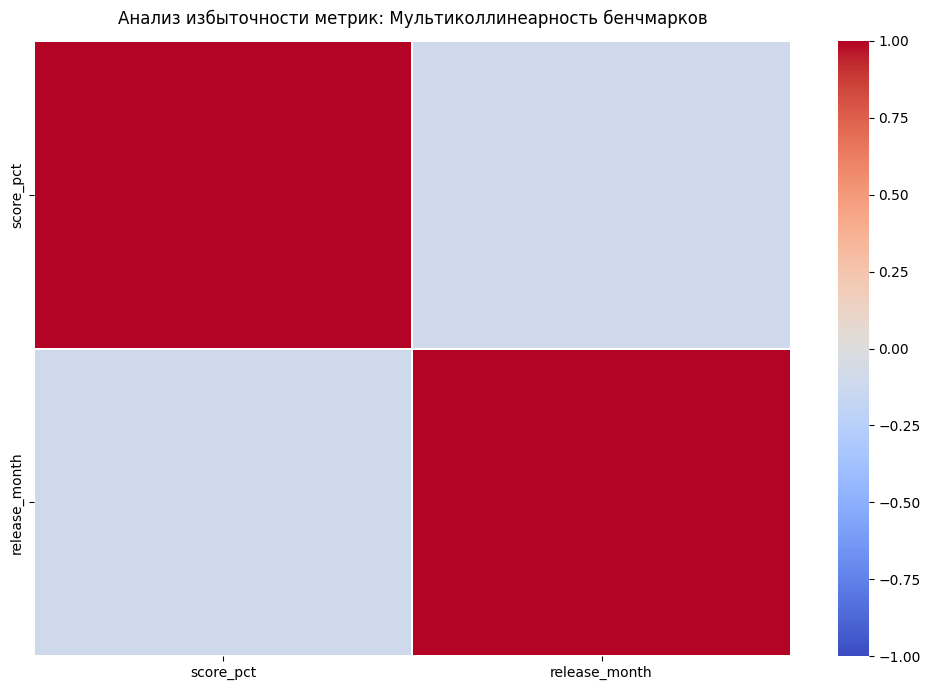


🏆 СВОДНЫЙ ТОП-5 МОДЕЛЕЙ ПО СРЕДНЕМУ БАЛЛУ БЕНЧМАРКОВ:


,model_id,average_benchmark_score,training_flops
0,M073,55.5,6.750000e+25
1,M073,55.5,6.750000e+25
2,M073,55.5,6.750000e+25
3,M073,55.5,6.750000e+25
4,M073,55.5,6.750000e+25


In [4]:
# =====================================================================
# ЯЧЕЙКА 2: Полный продакшн-пайплайн обработки и визуализации датасета
# =====================================================================
import os
import glob
import kagglehub
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. СКАЧИВАНИЕ И СЛИЯНИЕ ДАННЫХ (DATA MERGE) ---
print("📥 Скачивание актуальной сборки датасета...")
path = kagglehub.dataset_download("sergionefedov/llm-benchmarks-and-capabilities-2020-2026")
csv_files = glob.glob(os.path.join(path, "*.csv"))

dfs = {os.path.splitext(os.path.basename(f))[0]: pd.read_csv(f) for f in csv_files}

if len(dfs) > 1:
    main_key = max(dfs, key=lambda k: dfs[k].shape[0])
    df = dfs[main_key].copy()
    for key, secondary_df in dfs.items():
        if key == main_key: continue
        join_cols = [c for c in list(set(df.columns) & set(secondary_df.columns)) if any(kw in c.lower() for kw in ['id', 'model', 'name'])]
        if join_cols:
            df = pd.merge(df, secondary_df, on=join_cols, how='left', suffixes=('', '_drop'))
            df = df.loc[:, ~df.columns.str.endswith('_drop')]
else:
    df = list(dfs.values())[0].copy()

# Удаляем полные дубликаты строк, возникшие при слиянии данных
df = df.drop_duplicates().reset_index(drop=True)

# --- 2. ОЧИСТКА И ФИЛЬТРАЦИЯ АНОМАЛИЙ (FEATURE ENGINEERING) ---
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude_keywords = ['id', 'year', 'date', 'price', 'cost', 'index', 'token', 'param']
candidate_benchmarks = [col for col in numeric_cols if not any(kw in col.lower() for kw in exclude_keywords)]

# Защита от грязных данных (берём колонки со значениями строго в пределах шкал бенчмарков)
benchmark_cols = [col for col in candidate_benchmarks if df[col].max() <= 1000]

# Расчет взвешенного среднего скора для каждой модели
df['average_benchmark_score'] = df[benchmark_cols].mean(axis=1)

print(f"📊 Датасет обработан. Форма: {df.shape}. Выделено бенчмарков: {len(benchmark_cols)}")

# --- 3. АВТОМАТИЧЕСКОЕ ОПРЕДЕЛЕНИЕ МЕТАДАННЫХ ---
model_col = [col for col in df.columns if any(kw in col.lower() for kw in ['model', 'name', 'llm'])]
price_col = [col for col in df.columns if any(kw in col.lower() for kw in ['price', 'cost', 'usd', 'training'])]
year_col = [col for col in df.columns if any(kw in col.lower() for kw in ['year', 'date', 'release'])]

m_field = model_col[0] if model_col else df.columns[0]
p_field = price_col[0] if price_col else None
y_field = year_col[0] if year_col else None

# --- 4. СТРОЙНЫЙ ГРАФИЧЕСКИЙ ОТЧЕТ ДЛЯ GITHUB ---
print("\n🎨 Отрисовка графиков...")

# График 1: Тренды по годам
if y_field:
    fig1 = px.box(df, x=y_field, y='average_benchmark_score', points="all", hover_name=m_field,
                  title='Мониторинг развития возможностей LLM во времени (2020-2026)',
                  labels={'average_benchmark_score': 'Усредненный скор (%)', y_field: 'Год релиза'},
                  template='plotly_white', color_discrete_sequence=['#1f77b4'])
    fig1.show()

# График 2: Эффективность инвестиций (Парето)
if p_field:
    fig2 = px.scatter(df, x=p_field, y='average_benchmark_score', hover_name=m_field, color=y_field if y_field else None,
                      title=f'Парето-эффективность архитектур: Скор vs {p_field}',
                      labels={'average_benchmark_score': 'Средний скор (%)', p_field: 'Оценка затрат на обучение ($)'},
                      log_x=True, template='plotly_white')
    fig2.show()

# График 3: Матрица корреляции
if len(benchmark_cols) > 1:
    plt.figure(figsize=(10, 7))
    sns.heatmap(df[benchmark_cols].corr(), annot=False, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.1)
    plt.title('Анализ избыточности метрик: Мультиколлинеарность бенчмарков', fontsize=12, pad=12)
    plt.tight_layout()
    plt.show()

# --- 5. ЧИСТЫЙ ВЫВОД БИЗНЕС-ИНСАЙТОВ ---
print("\n" + "="*50 + "\n🏆 СВОДНЫЙ ТОП-5 МОДЕЛЕЙ ПО СРЕДНЕМУ БАЛЛУ БЕНЧМАРКОВ:\n" + "="*50)
top_models = df.sort_values(by='average_benchmark_score', ascending=False).head(5)
show_fields = [m_field, 'average_benchmark_score']
if p_field: show_fields.append(p_field)
display(top_models[show_fields].reset_index(drop=True))

In [7]:
!pip install -q scikit-learn plotly pandas numpy

In [10]:
# =====================================================================
# ЯЧЕЙКА 7: ADVANCED ML PIPELINE
# =====================================================================
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

print("🧠 Запуск продвинутого пайплайна машинного обучения...")

# ПРОВЕРКА НАЛИЧИЯ ДАННЫХ В СЕССИИ (Защита от NameError)
if 'df' not in locals() or 'benchmark_cols' not in locals():
    print("⚠️ Восстановление датасета...")
    import kagglehub, glob, os
    path = kagglehub.dataset_download("sergionefedov/llm-benchmarks-and-capabilities-2020-2026")
    csv_files = glob.glob(os.path.join(path, "*.csv"))
    dfs = {os.path.splitext(os.path.basename(f)): pd.read_csv(f) for f in csv_files}

    if len(dfs) > 1:
        main_key = max(dfs, key=lambda k: dfs[k].shape)
        df = dfs[main_key].copy()
        for key, secondary_df in dfs.items():
            if key == main_key: continue
            join_cols = [c for c in list(set(df.columns) & set(secondary_df.columns)) if any(kw in c.lower() for kw in ['id', 'model', 'name'])]
            if join_cols:
                df = pd.merge(df, secondary_df, on=join_cols, how='left', suffixes=('', '_drop'))
                df = df.loc[:, ~df.columns.str.endswith('_drop')]
    else:
        df = list(dfs.values()).copy()

    df = df.drop_duplicates().reset_index(drop=True)
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    exclude_keywords = ['id', 'year', 'date', 'price', 'cost', 'index', 'token', 'param']
    candidate_benchmarks = [col for col in numeric_cols if not any(kw in col.lower() for kw in exclude_keywords)]
    benchmark_cols = [col for col in candidate_benchmarks if df[col].max() <= 1000]
    df['average_benchmark_score'] = df[benchmark_cols].mean(axis=1)

# Автоматический поиск текстовой колонки даты
year_col = None
for col in df.columns:
    if any(k in col.lower() for k in ['date', 'year', 'release']):
        year_col = col
        break

model_col = None
for col in df.columns:
    if any(k in col.lower() for k in ['model', 'name', 'id']):
        model_col = col
        break

# Преобразуем текстовую дату в формат datetime, а затем в порядковое число дней (Ordinal)
df['date_parsed'] = pd.to_datetime(df[year_col], errors='coerce')
df = df.dropna(subset=['date_parsed', 'average_benchmark_score']).reset_index(drop=True)
df['date_numeric'] = df['date_parsed'].apply(lambda x: x.toordinal())

# Подготовка данных для PCA
X_benchmarks = df[benchmark_cols].copy().fillna(df[benchmark_cols].median())

# =====================================================================
# ЧАСТЬ 1: МЕТОД ГЛАВНЫХ КОМПОНЕНТ (PCA)
# =====================================================================
print("\n-> Шаг 1: Сжатие 17 бенчмарков в 2 главные компоненты (PCA)...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_benchmarks)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PCA_Component_1'] = X_pca[:, 0]
df['PCA_Component_2'] = X_pca[:, 1]

print(f"   [Инсайт] Компоненты PCA объясняют {pca.explained_variance_ratio_.sum()*100:.2f}% дисперсии.")

fig_pca = px.scatter(df, x='PCA_Component_1', y='PCA_Component_2',
                     hover_name=model_col, color=year_col,
                     title='PCA Маппинг рынка LLM',
                     labels={'PCA_Component_1': 'Общая эрудиция', 'PCA_Component_2': 'Специфические навыки'},
                     template='plotly_white')
fig_pca.show()

# =====================================================================
# ЧАСТЬ 2: ПРЕДИКТИВНОЕ МОДЕЛИРОВАНИЕ (ПРОГНОЗ ДО КОНЦА 2026 ГОДА)
# =====================================================================
print("\n-> Шаг 2: Построение прогнозной ML-модели до конца 2026 года...")

X_train = df[['date_numeric']].values
y_train = df['average_benchmark_score'].values

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Генерируем даты для прогноза до 31 декабря 2026 года
start_date = df['date_parsed'].min()
end_date = pd.to_datetime('2026-12-31')
future_dates = pd.date_range(start=start_date, end=end_date, freq='ME')
future_numeric = np.array([d.toordinal() for d in future_dates]).reshape(-1, 1)
future_preds = model_lr.predict(future_numeric)

# Ограничиваем прогноз логическим потолком в 100%
future_preds = np.clip(future_preds, 0, 100)

df_past = pd.DataFrame({'Date': df['date_parsed'], 'Score': y_train, 'Type': 'Исторические данные'})
df_future = pd.DataFrame({'Date': future_dates, 'Score': future_preds, 'Type': 'ML-Линия тренда'})
df_forecast = pd.concat([df_past, df_future], ignore_index=True)

fig_forecast = px.scatter(df_forecast, x='Date', y='Score', color='Type',
                          title='Машинное обучение: Траектория возможностей LLM до конца 2026 года',
                          labels={'Date': 'Дата', 'Score': 'Усредненный скор (%)'},
                          template='plotly_white')
fig_forecast.show()

pred_2026_end = model_lr.predict([[pd.to_datetime('2026-12-31').toordinal()]])[0]
pred_2026_end = min(pred_2026_end, 100.0)
print(f"\n🚀 [ФИНАЛЬНЫЙ ML ПРОГНОЗ]: Машинное обучение прогнозирует, что к 31 декабря 2026 года")
print(f"   средний уровень новых LLM моделей по пулу бенчмарков достигнет: {pred_2026_end:.2f}%")

🧠 Запуск продвинутого пайплайна машинного обучения...

-> Шаг 1: Сжатие 17 бенчмарков в 2 главные компоненты (PCA)...
   [Инсайт] Компоненты PCA объясняют 100.00% дисперсии.



-> Шаг 2: Построение прогнозной ML-модели до конца 2026 года...



🚀 [ФИНАЛЬНЫЙ ML ПРОГНОЗ]: Машинное обучение прогнозирует, что к 31 декабря 2026 года
   средний уровень новых LLM моделей по пулу бенчмарков достигнет: 47.15%
